# 04 — MCMC Fitting a Prism Spectrum

This notebook demonstrates the `jwspecmcmc` MCMC workflow:
1. Load a JWST NIRSpec PRISM spectrum
2. Fit emission lines with `emcee` (MCMC) — BIC broad selection is on by default
3. Compare MCMC posteriors with bootstrap uncertainties from `jwspecfit`
4. Inspect asymmetric credible intervals
5. Compute flux-ratio posteriors for line-ratio diagnostics
6. Diagnostic plots: corner, traces, flux posteriors
7. Use `to_fit_result()` for compatibility with `jwspecfit.plot_fit()`

By default, `jwspecmcmc.fit_lines()` performs BIC-based broad Balmer
component selection before MCMC sampling.  Set `mode="off"` for
narrow-only fitting.

In [1]:
import jwspecfit
import jwspecmcmc
import matplotlib.pyplot as plt
import numpy as np
import numpyro
numpyro.set_host_device_count(6)

print(f"jwspecfit  v{jwspecfit.__version__}")
print(f"jwspecmcmc v{jwspecmcmc.__version__}")

jwspecfit  v1.0.1
jwspecmcmc v1.0.1


## Load the spectrum

Same PRISM spectrum as notebook 01.

In [2]:
spec = jwspecfit.read_fits("../../data/borg-v4_prism-clear_1747_732.spec.fits", z=8.22288)

print(f"Grating:    {spec.grating}")
print(f"Pixels:     {spec.n_pix}")
print(f"Wave range: {spec.wave_um.min():.3f} \u2013 {spec.wave_um.max():.3f} \u00b5m")

Grating:    PRISM
Pixels:     473
Wave range: 0.540 – 5.515 µm


## MCMC fit with nuts

A single call mirrors `jwspecfit.fit_lines()` but uses MCMC sampling.
By default it runs BIC broad-component selection (fast least-squares),
then initialises walkers from the MLE and samples with nuts on the
winning model.


In [15]:
import jwspecfit
from jwspecfit.lines import REST_LINES_A
from jwspecfit.resolution import R_from_pixels
from jwspecabund.dust import salim_attenuation, compute_Av_from_balmer
from jwspecabund.forward import hbeta_emissivity_aller84, _nv_emissivity
import matplotlib.pyplot as plt
import numpy as np
import pyneb as pn


print(f"jwspecfit  v{jwspecfit.__version__}")
print(f"pyneb     v{pn.__version__}")

lines=['HBETA','OIII_4959','OIII_5007','HGAMMA','OIII_4363','OII_doublet']

result = jwspecmcmc.fit_lines(
    spec, z=8.22288,
    sampler="nuts",
    n_warmup=500, 
    n_samples_nuts=2000, 
    n_chains=6,
    n_boot_bic=0,  
    seed=42,
    lines=lines,
)

print(f"Selected:    {result.selected_model}")
print(f"Sampler:     {result.sampler_name}")
print(f"Lines:       {', '.join(result.lines.keys())}")
print(f"Chain shape: {result.flat_chains.shape}")
print(f"Burn-in:     {result.sampler_meta.get('n_burn', '?')} steps")

jwspecfit  v1.0.1
pyneb     v1.1.28
Resolving power: R ≈ 272 (range 30–300)
Resolving power: R ≈ 272 (range 30–300)
Resolving power: R ≈ 272 (range 30–300)


  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

  0%|          | 0/2500 [00:00<?, ?it/s]

Selected:    narrow
Sampler:     nuts
Lines:       HBETA, OIII_4959, OIII_5007, HGAMMA, OIII_4363, OII_doublet
Chain shape: (12000, 18)
Burn-in:     ? steps


In [16]:
fig = jwspecfit.plot_fit_interactive(result)
fig

## Per-line results with asymmetric uncertainties

MCMC gives proper (16th, 84th) percentile credible intervals,
which can be asymmetric for parameters near bounds.

In [17]:
print(f"{'Line':<18s} {'Flux':>12s} {'\u2212err':>12s} {'+err':>12s} {'SNR':>8s} {'EW (\u00c5)':>10s}")
print("-" * 76)
for name, lr in result.lines.items():
    print(
        f"{name:<18s} {lr.flux:12.3e} {lr.flux_err[0]:12.3e} {lr.flux_err[1]:12.3e}"
        f" {lr.snr:8.1f} {lr.ew_A:10.1f}"
    )

Line                       Flux         −err         +err      SNR     EW (Å)
----------------------------------------------------------------------------
HBETA                 1.223e-18    1.950e-19    1.972e-19      6.2       68.6
OIII_4959             1.957e-18    2.073e-19    2.097e-19      9.4      118.5
OIII_5007             7.657e-18    2.604e-19    2.563e-19     29.6      480.1
HGAMMA                5.113e-19    1.884e-19    1.785e-19      2.8       19.7
OIII_4363             3.524e-19    1.661e-19    1.836e-19      2.0       13.8
OII_doublet           7.453e-19    2.138e-19    2.120e-19      3.5       18.8


## Convergence diagnostics

The Gelman\u2013Rubin R-hat should be < 1.05 and the effective sample
size (ESS) should be > 100 for all parameters.

In [18]:
conv = result.convergence
print(f"R-hat max:  {conv.get('r_hat_max', 'N/A'):.3f}")
print(f"ESS min:    {conv.get('ess_min', 'N/A'):.0f}")
print(f"Converged:  {conv.get('converged', 'N/A')}")

R-hat max:  1.000
ESS min:    7708
Converged:  True


## Trace plots

Inspect how the chains explore parameter space.  Good chains
should look like "hairy caterpillars" with no trends.

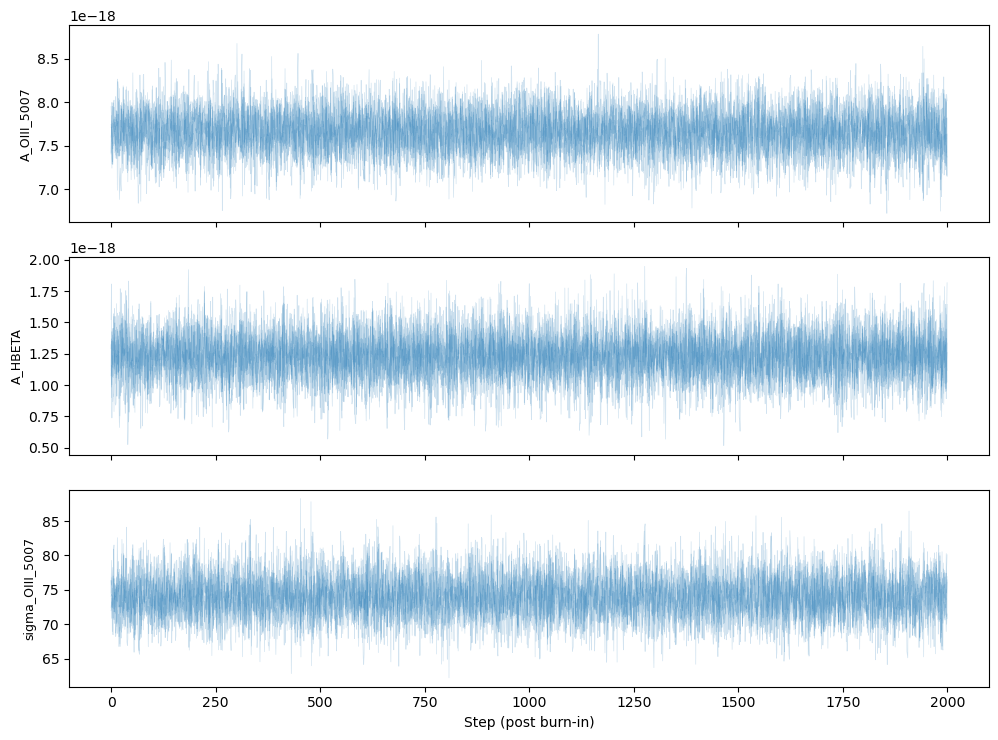

In [19]:
fig = jwspecmcmc.plot_traces(
    result,
    params=["A_OIII_5007", "A_HBETA", "sigma_OIII_5007"],
)
plt.show()

## Flux posterior histograms

The full posterior distribution of the [OIII] 5007 flux, with
median and 68% credible interval.

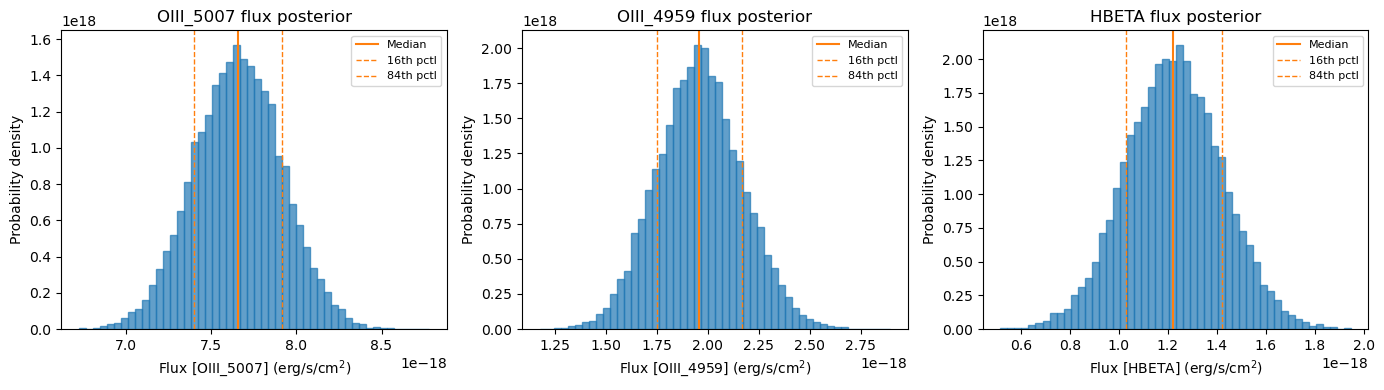

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, line in zip(axes, ["OIII_5007", "OIII_4959", "HBETA"]):
    if line in result.lines:
        jwspecmcmc.plot_flux_posterior(result, line, ax=ax)

plt.tight_layout()
plt.show()

## Corner plot

Joint posterior of selected parameters.  Off-diagonal panels show
covariances between parameters.

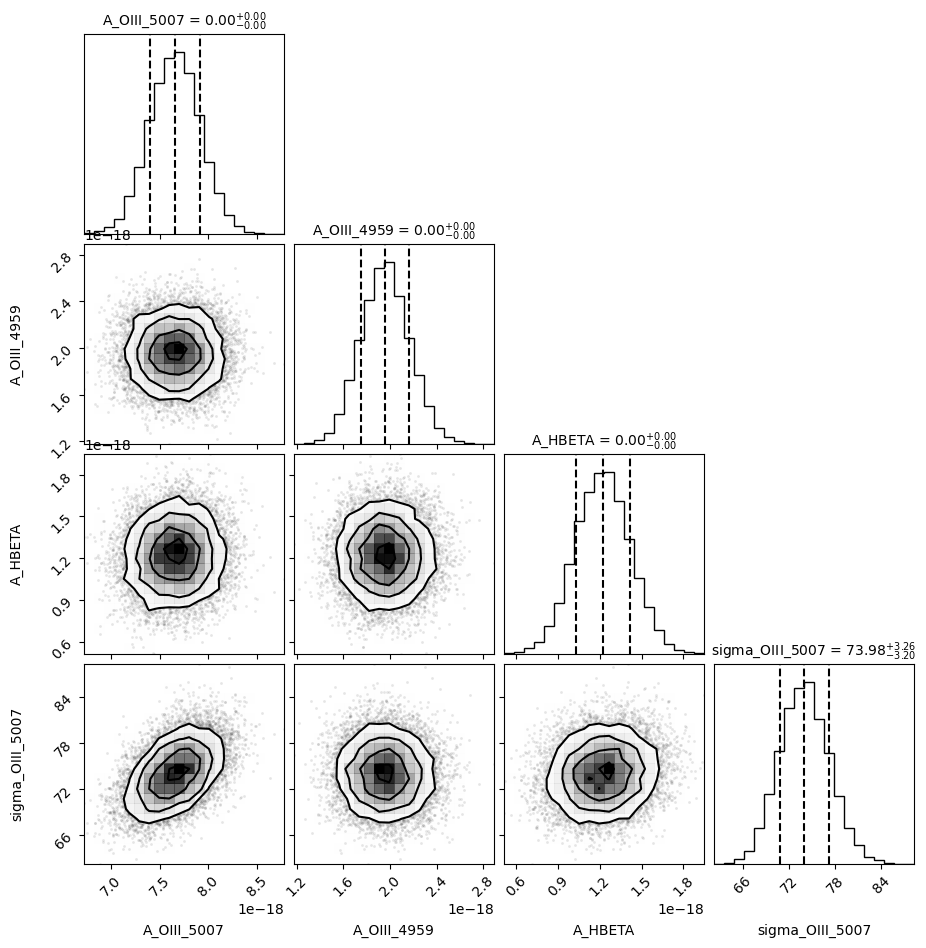

In [21]:
fig = jwspecmcmc.plot_corner(
    result,
    params=["A_OIII_5007", "A_OIII_4959", "A_HBETA", "sigma_OIII_5007"],
)
plt.show()

## Flux-ratio posteriors

Compute the posterior on O3/H\u03b2 = [OIII] 5007 / H\u03b2,
which is a key diagnostic for metallicity and ionisation.

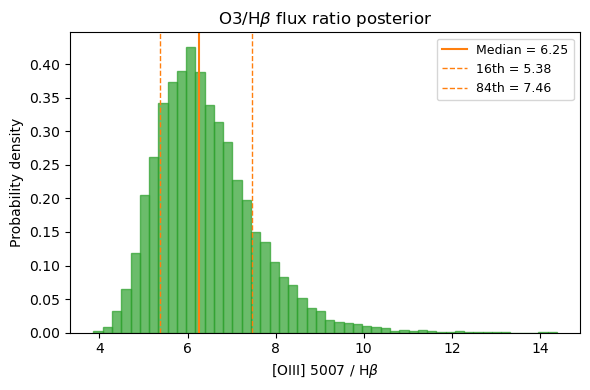

In [22]:
if "OIII_5007" in result.lines and "HBETA" in result.lines:
    ratio = result.flux_ratio_posterior("OIII_5007", "HBETA")
    ratio_clean = ratio[np.isfinite(ratio)]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(ratio_clean, bins=50, density=True, alpha=0.7, color="C2", edgecolor="C2")
    med = np.median(ratio_clean)
    lo, hi = np.percentile(ratio_clean, [16, 84])
    ax.axvline(med, color="C1", ls="-", lw=1.5, label=f"Median = {med:.2f}")
    ax.axvline(lo, color="C1", ls="--", lw=1.0, label=f"16th = {lo:.2f}")
    ax.axvline(hi, color="C1", ls="--", lw=1.0, label=f"84th = {hi:.2f}")
    ax.set_xlabel(r"[OIII] 5007 / H$\beta$")
    ax.set_ylabel("Probability density")
    ax.legend(fontsize=9)
    ax.set_title(r"O3/H$\beta$ flux ratio posterior")
    plt.tight_layout()
    plt.show()
else:
    print("OIII_5007 or HBETA not in fitted lines.")